# Solução 02: Baseado em similaridade

Esta solução visa dar o *match* entre um template fixado com os contornos de objetos encontrados, utilizando a biblioteca `OpenCV`.

# Imports

In [1]:
from nb_utils import set_root
PROJECT_DIR = set_root(1)

In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt
import cv2

# Methods

In [3]:
def find_contorno(imagem: np.ndarray):
    """Verifica se a imagem contém a letra A maiúscula"""
    # Binariza a imagem (inversão: fundo branco, letras pretas)
    _, img_bin = cv2.threshold(imagem, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # Encontra contornos (possíveis letras)
    contornos, _ = cv2.findContours(img_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    return contornos, img_bin

def tm_ccoef_normed(image: np.ndarray, template: np.ndarray) -> np.ndarray:
    """
    Calcula a correlação cruzada normalizada (TM_CCOEFF_NORMED) entre a imagem e o template.

    Parâmetros:
    - image: imagem de entrada (2D, em escala de cinza)
    - template: template a ser comparado (2D, em escala de cinza)

    Retorna:
    - result: mapa de similaridade (valores entre -1 e 1)
    """
    img_h, img_w = image.shape
    tpl_h, tpl_w = template.shape

    # Média e T' do template
    template_mean = np.mean(template)
    template_prime = template - template_mean
    template_prime_squared_sum = np.sum(template_prime ** 2)

    # Saída terá tamanho reduzido
    result_h = img_h - tpl_h + 1
    result_w = img_w - tpl_w + 1
    result = np.zeros((result_h, result_w), dtype=np.float32)

    # Para cada posição possível (x, y) na imagem:
    for y in range(result_h):
        for x in range(result_w):
            region = image[y:(y + tpl_h), x:(x + tpl_w)]
            region_mean = np.mean(region)
            region_prime = region - region_mean
            region_prime_squared_sum = np.sum(region_prime ** 2)

            numerator = np.sum(template_prime * region_prime)
            denominator = np.sqrt(template_prime_squared_sum * region_prime_squared_sum)

            result[y, x] = numerator / denominator if denominator != 0 else 0.0

    return result


# Parameters

In [4]:
path_assets = PROJECT_DIR / 'assets'

# Questão 08

## 1) Leituras das imagens

In [5]:
# Leitura de imagens
file_path_template_A = str(path_assets / "atv02-q08-01_template_A.png")
image_path_1 = str(path_assets / "atv02_lista02-assets" / "Book_1.png")
image_path_2 = str(path_assets / "atv02_lista02-assets" / "Book_2.png")

image_template = cv2.imread(file_path_template_A, cv2.IMREAD_GRAYSCALE)
image_book_1 = cv2.imread(image_path_1, cv2.IMREAD_GRAYSCALE)
image_book_2 = cv2.imread(image_path_2, cv2.IMREAD_GRAYSCALE)

# parametros para salvar
imgs = {
    "Book_1": image_book_1,
    "Book_2": image_book_2,
    "Template_A": image_template
}
books_name = ["Book_1", "Book_2"]

contents ={
    name: {
        "contornos": [],
        "letra": [],
        "letra_norm": [],
        "similarity": [],
        "check_is_valid": []
    } for name in books_name
}

## 2) Geração de contornos

Nesse trecho, primeiro sera feito a inversão da cor da imagem, fundo branco com letra preta, será invertido para fundo preto com letra branca, para facilitar a detecção dos contornos.

In [6]:
# Pega os contornos e a imagem binarizada
imgs_processed = {}
for name, img in imgs.items():  # fazendo para todas as imagens
    imgs_processed[name] = {}
    imgs_processed[name]["contornos"], imgs_processed[name]["img_bin"] = find_contorno(img)

    # Faz uma cópia colorida da imagem original (para desenhar colorido)
    imgs_processed[name]["img_com_contornos"] = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

    # Desenha os contornos
    _ = cv2.drawContours(
        imgs_processed[name]["img_com_contornos"],
        imgs_processed[name]["contornos"],
        -1,
        (0, 255, 0),
        1
    )

### 1.3) Ilustração do processo de binarização e contornos

Abaixo temos a imagem binarizada, apos a inversão e ao lado o contorno de cada letra encontrada.

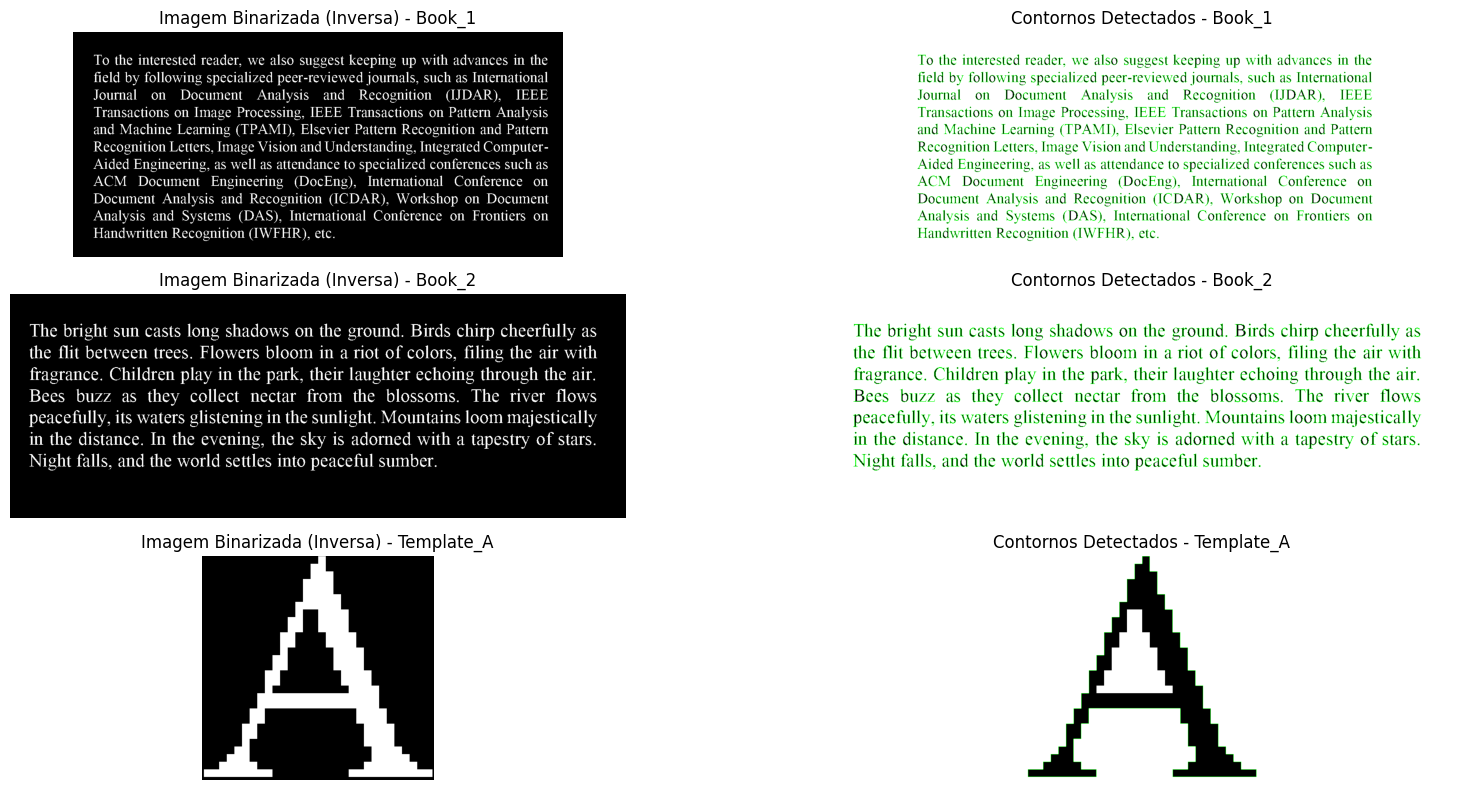

In [7]:
# Mostra imagem binarizada e com contornos lado a lado
fig1, ax1 = plt.subplots(len(imgs_processed), 2, figsize=(18, 8))
for idx, name in enumerate(imgs_processed.keys()):
    ax1[idx, 0].imshow(imgs_processed[name]["img_bin"], cmap='gray')
    ax1[idx, 0].set_title("Imagem Binarizada (Inversa) - {}".format(name))
    ax1[idx, 0].axis('off')

    ax1[idx, 1].imshow(imgs_processed[name]["img_com_contornos"], cmap='gray')
    ax1[idx, 1].set_title("Contornos Detectados - {}".format(name))
    ax1[idx, 1].axis('off')

fig1.tight_layout()
fig1.savefig(path_assets / "atv02-q08-i01_k03.png", dpi=400, bbox_inches='tight')
plt.show()

## 3) Busca de similaridade com o template utilizado

Abaixo, será aplicado a cada contorno encontrado um calculo de similaridade (`TM_CCOEFF_NORMED`), com a implementação disponibilizada pela [*OpenCV*](https://docs.opencv.org/4.x/df/dfb/group__imgproc__object.html). A formula para essa similidade pode ser expressa pela equação abaixo:

$$
R(x, y) = \frac{\sum_{x^{'}, y^{'}} (T^{'}(x^{'}, y^{'}) \cdot I^{'}(x + x^{'}, y + y^{'}))}{\sqrt{\sum_{x^{'}, y^{'}} T^{'}(x^{'}, y^{'})^{2} \cdot \sum_{x^{'}, y^{'}} I^{'}(x + x^{'}, y + y^{'})^{2}}}
$$

Abaixo, será  calculado e armazenado as similidades, por meio de uma função criada, além de visualizar uma pequena amostra de letras e suas respectivas similaridades.

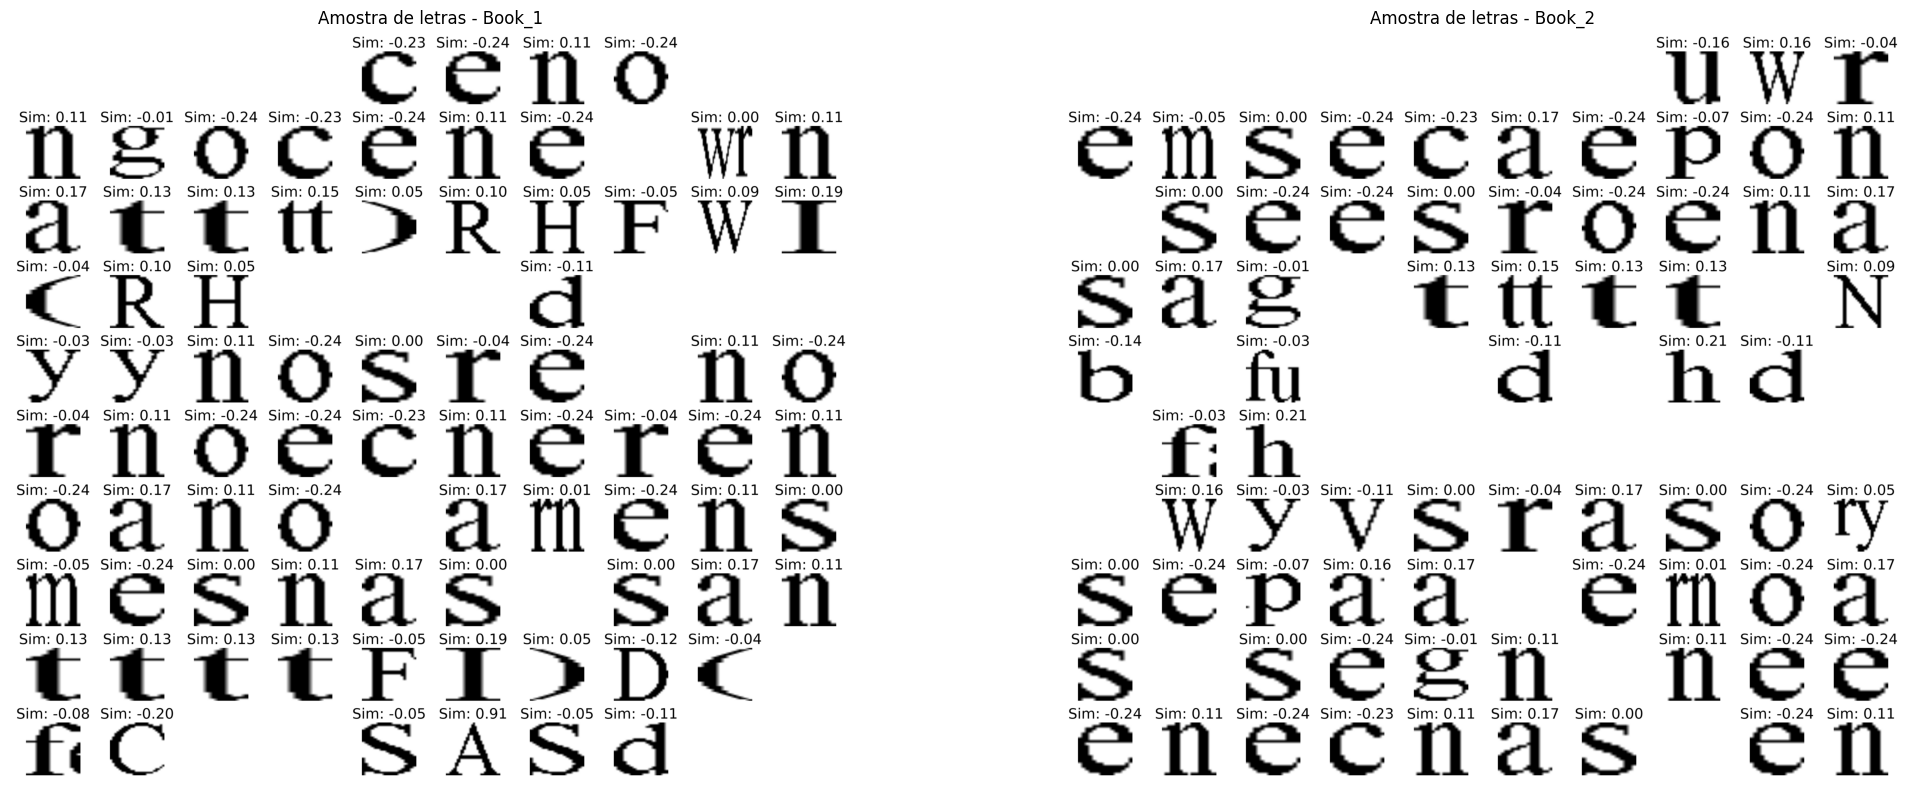

In [8]:
file_paths_imgs = {}
for name in books_name:
    fig, ax = plt.subplots(10, 10, figsize=(18, 16))
    ax = ax.flatten()
    for i, contorno in enumerate(imgs_processed[name]["contornos"]):
        x, y, w, h = cv2.boundingRect(contorno)

        letra = imgs_processed[name]["img_bin"][y:(y + h), x:(x + w)]  # recorta a letra da iamgem
        letra_resized = cv2.resize(
            letra,
            (imgs_processed["Template_A"]["img_bin"].shape[1], imgs_processed["Template_A"]["img_bin"].shape[0])
        )  # redimensiona para o tamanho do template

        letra_norm = 1 - letra_resized / 255.0 # re normalizando para retornar com o fundo branco e letra preta

        # Outro formato de uso usando a biblioteca OpenCV ###############################################################
        # res = cv2.matchTemplate(
        #     letra_norm.astype(np.float32),
        #     image_template.astype(np.float32),
        #     cv2.TM_CCOEFF_NORMED
        # )[0][0]  # calculo de similaridade explicitado
        #################################################################################################################
        res = tm_ccoef_normed(letra_norm, image_template)  # calculo de similaridade
        # simililarity = res[0][0]
        simililarity = res[0][0]

        contents[name]["contornos"].append(contorno)
        contents[name]["letra"].append(letra)
        contents[name]["letra_norm"].append(letra_norm)
        contents[name]["similarity"].append(simililarity)

        if w < 10 or h < 10:  # contornos muito pequenos não serão mostrados
            if i < (10 * 10):
                ax[i].axis("off")
            contents[name]["check_is_valid"].append(False)
            continue
        contents[name]["check_is_valid"].append(True)

        if i < (10 * 10):
            ax[i].imshow(letra_norm, cmap='gray')
            ax[i].axis("off")
            ax[i].set_title(f"Sim: {simililarity:.2f}", fontsize=22)
    fig.tight_layout()
    file_paths_imgs[name] = path_assets / f"atv02-q08-i01_{name.lower()}.png"
    fig.savefig(file_paths_imgs[name], dpi=400, bbox_inches='tight')
    # fig.suptitle("Amostra de letras e similaridade calculada")
    plt.close()

# Mostra amostra de letras extraídas, juntas
fig, ax = plt.subplots(1, 2, figsize=(22, 8))
for idx, (name, file_path) in enumerate(file_paths_imgs.items()):
    img = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)
    ax[idx].imshow(img, cmap = 'gray')
    ax[idx].set_title(f"Amostra de letras - {name}")
    ax[idx].axis("off")

fig.tight_layout()
fig.savefig(path_assets / "atv02-q08-i01_k04.png", dpi=400, bbox_inches='tight')
plt.show()

## 4) Threshold para similaridade

Considerando o  calculo utilizado para a similaridade, será utilizado um *threshold* de $0.5$ para a métrica utilizada, aonde temos:

$$
\text{Resultado} = 
\begin{cases} 
\text{Letra 'A' encontrada}, & \text{se } thres \geq 0.5 \\
\text{Letra 'A' não encontrada}, & \text{se } thres < 0.5
\end{cases}
$$

Logo, aplicando esse calculo temos:

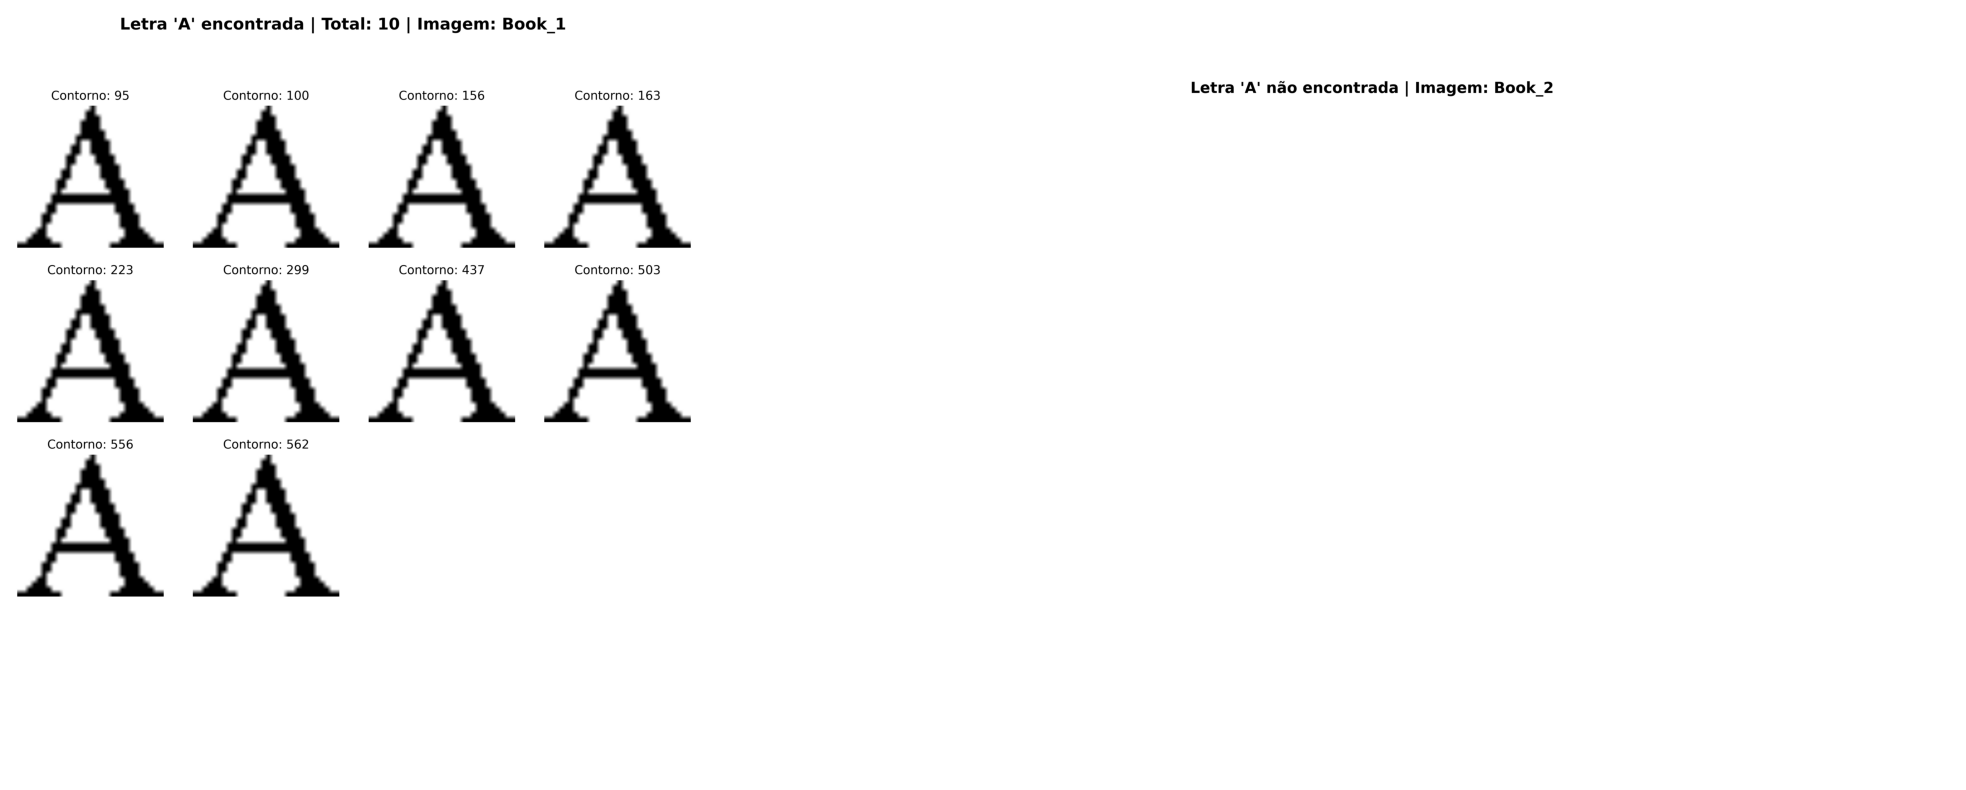

In [17]:
p = 0.5
file_paths_found = {}
for name in books_name:
    ks = np.where((np.array(contents[name]["similarity"]) >= p) & (np.array(contents[name]["check_is_valid"]) == True))[0]
    n = math.ceil(math.sqrt(len(ks)))
    contents[name]["contains_A"] = len(ks) > 0
    contents[name]["total-of_A"] = len(ks)
    file_paths_found[name] = path_assets / f"atv02-q08-i01_{name.lower()}_found.png"
    if n != 0:
        fig, axes = plt.subplots(
            n,
            n,
            figsize=(n * 3, n * 3)
        )


        for value, _axes in zip(ks, axes.flatten()):
            _axes.imshow(contents[name]["letra_norm"][value], cmap="gray")
            _axes.set_title(f"Contorno: {value}")

        for _axes in axes.flatten():
            _axes.axis('off')

        text = f"Letra 'A' {'encontrada' if len(ks) >= 1 else 'inexistente'}"
        text += f" | Total: {len(ks)}"
        text += f" | Imagem: {name}"
        fig.suptitle(text, fontsize=16, weight='bold')
        fig.savefig(file_paths_found[name], dpi=400, bbox_inches='tight')
        # plt.close()
    else:
        fig, axes = plt.subplots(
            1,
            1,
            figsize=(16, 8)
        )
        fig.suptitle(f"Letra 'A' não encontrada | Imagem: {name}", weight='bold')
        axes.axis('off')
        fig.savefig(file_paths_found[name], dpi=400, bbox_inches='tight')
    fig.tight_layout()
    plt.close()

# Mostra amostra de letras extraídas, juntas
fig, ax = plt.subplots(1, 2, figsize=(22, 8))
for idx, (name, file_path) in enumerate(file_paths_found.items()):
    img = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)
    ax[idx].imshow(img, cmap = 'gray')
    # ax[idx].set_title(f"Amostra de letras - {name}")
    ax[idx].axis("off")

fig.tight_layout()
fig.savefig(path_assets / "atv02-q08-i01_all-found.png", dpi=400, bbox_inches='tight')
plt.show()

## 5) Conclusão

In [19]:
for key, content in contents.items():
    print("-" * 30)
    print(key.split(" - ")[0])
    print(f"Possuí a letra A: {content['contains_A']}")
    if content["contains_A"]:
        print(f"Total de letra A: {content['total-of_A']}")
print("-"*30)

------------------------------
Book_1
Possuí a letra A: True
Total de letra A: 10
------------------------------
Book_2
Possuí a letra A: False
------------------------------


Apos a aplicação dessa solução, temos:

1) **Book_1:** como para a solução anterior (`01`), a letra `A` foi detectada na imagem, além de terem sido identificados 10 letras na imagem, e com esse método é possivel mensurar o quão parecidas o objeto e o template são.

2) **Book_2:** também como na solução anterior, a letra `A` não foi detectada na imagem, uma vez que consideramos o `threshold` para a similaridade de `0.5`.